This notebook records the creation of the `SHENDURE_BOUNDS` preset object.

In [ ]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-08-18 16:49:41.783476: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-18 16:49:41.787872: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-08-18 16:49:41.787883: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [ ]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-08-18 16:50:21,351 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43309' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-548b876316c92f23a3a435f1e0fe7ca0', 'lambda-c24e62e2fa1a368016cf87008e131078', 'lambda-63bd79e60bb6bbabdac5df6f1151bdb2', 'lambda-8a37d3c08de587d2612708d34f339826', 'lambda-91e85c928d95af7aaad447b91eafe426', 'lambda-3ce67c2d455656e2d7a62102625bc8a2', 'lambda-9229bc17a27b67e812902bf981c5c0fb', 'lambda-fc07a339e83c7e58d8161e99c2f9fa91', 'lambda-1d6598198fff0356ad3da559ba622db2', 'lambda-f2ec6a89d533f801ea60fb7ebd5169cd', 'lambda-933800c4a0e9345b9f1650370de33e6c', 'lambda-87b6d84fb6e5c586d47b1f3dc0f9a216', 'lambda-c3d3b6870cd1efdcd7d764f5a33f5bc2', 'lambda-419a561bbb545e7774084bbdaac7231e', 'lambda-ce0b63c8f5a0572493f4116acedae53e', 'lambda-cf101aead4da2c29a894c489d4dab200', 'lambda-310f849e7a2139cefaadfd050177f24d', 'lambda-5c17d7f4d6498eba0e0d2a6cc9fb81a7', 'lambda-c973339cad82018cc1f288e7a085

In [2]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

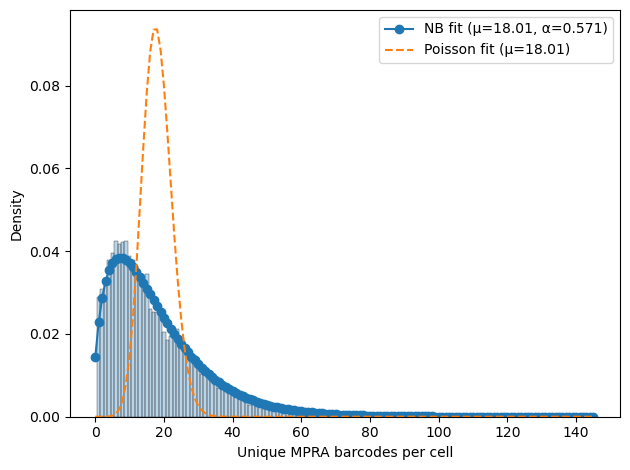

{'poisson_mu': 18.01055567079212,
 'nb_mu': 18.010555670792133,
 'nb_alpha': 0.5705626300443596}

In [3]:
primordial.training_data.describe_transfection(plot=True)

In [4]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

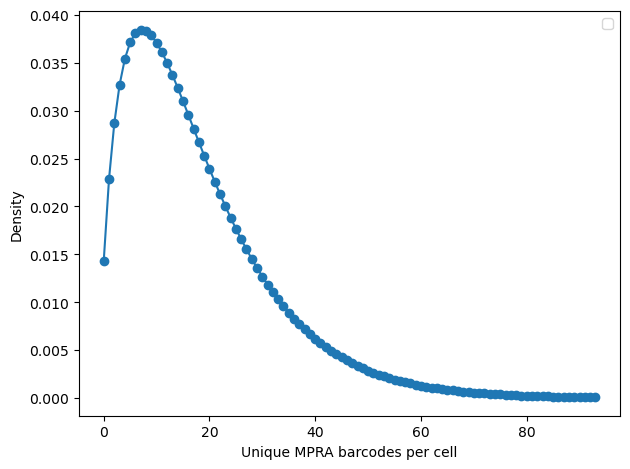

In [5]:
shendure_bounds.plot_transfection()

In [6]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [7]:
cluster.close()